# Logistic Regression as Convex Optimization

This notebook formulates $\ell_1$-regularized logistic regression as a convex optimization problem and solves it with CVXPY. Logistic regression is one of the most widely used classification methods, and its loss function is convex, making it a natural application of the optimization tools developed in this course.

**Learning objectives.** After working through this notebook you should be able to:
1. Derive the log-likelihood for logistic regression and verify it is concave in $\beta$.
2. Understand how $\ell_1$-regularization promotes sparsity in the coefficient vector.
3. Use CVXPY to solve the regularized maximum-likelihood problem.
4. Select the regularization parameter $\lambda$ via a train/test error trade-off.

## Mathematical Formulation

Given data $(x_i, y_i)$ with $x_i \in \mathbb{R}^n$ and $y_i \in \{0,1\}$, the logistic model assumes

$$
\Pr(Y = 1 \mid X = x) = \sigma(\beta^\top x) = \frac{\exp(\beta^\top x)}{1 + \exp(\beta^\top x)}.
$$

The **negative log-likelihood** (to be minimized) is

$$
\min_{\beta} \; -\sum_{i=1}^m \bigl[ y_i \beta^\top x_i - \log(1 + \exp(\beta^\top x_i)) \bigr] + \lambda \|\beta\|_1.
$$

**Why is this convex?** Each term $-y_i \beta^\top x_i + \log(1 + \exp(\beta^\top x_i))$ is convex in $\beta$ because $\log(1 + e^z)$ (the "softplus" function) is convex, and composing it with the linear function $\beta^\top x_i$ preserves convexity. The $\ell_1$-penalty $\lambda\|\beta\|_1$ is also convex, so the entire objective is convex.

In [1]:
import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt

## Synthetic Data Generation

We generate data with $n=50$ features by randomly sampling $x_i \in \mathbb{R}^{50}$ and using a **sparse** ground-truth coefficient vector $\beta_{\mathrm{true}}$ with only 3 nonzero entries (at indices 0, 1, 2). Labels are generated as $y_i = \mathbb{1}[\beta_{\mathrm{true}}^\top x_i + z_i > 0]$ where $z_i \sim \mathcal{N}(0, 0.25)$ is noise. We split into $m=50$ training and $2m=100$ test examples.

In [2]:
np.random.seed(1)
n = 50
m = 50
def sigmoid(z):
  return 1/(1 + np.exp(-z))

beta_true = np.array([1, 0.5, -0.5] + [0]*(n - 3))
X = (np.random.random((m, n)) - 0.5)*10
Y = np.round(sigmoid(X @ beta_true + np.random.randn(m)*0.5))

X_test = (np.random.random((2*m, n)) - 0.5)*10
Y_test = np.round(sigmoid(X_test @ beta_true + np.random.randn(2*m)*0.5))

### CVXPY Formulation

We define $\beta$ as a CVXPY variable and $\lambda$ as a parameter. The log-likelihood uses the CVXPY atom `cp.logistic(z)` $= \log(1 + e^z)$, which CVXPY recognizes as convex. The full objective is:

$$
\max_\beta \; \frac{1}{m}\sum_{i=1}^m \bigl[ y_i \beta^\top x_i - \log(1 + \exp(\beta^\top x_i)) \bigr] - \lambda \|\beta\|_1.
$$

The $\ell_1$-norm penalty encourages **sparsity**: for large enough $\lambda$, most components of $\widehat{\beta}$ will be exactly zero, performing automatic feature selection.

In [3]:
beta = cp.Variable(n)
lambd = cp.Parameter(nonneg=True)
log_likelihood = cp.sum(
    cp.multiply(Y, X @ beta) - cp.logistic(X @ beta) 
)
problem = cp.Problem(cp.Maximize(log_likelihood/m - lambd * cp.norm(beta, 1)))

### Regularization Path: Choosing $\lambda$

We solve the problem for a range of $\lambda$ values (on a log scale) and record the training and test classification errors. The **optimal $\lambda$** is the one that minimizes test error.

- **Small $\lambda$**: weak regularization, the model overfits (low train error, higher test error).
- **Large $\lambda$**: strong regularization, most coefficients are zero, the model underfits.
- **Optimal $\lambda$**: balances bias and variance.

In [4]:
def error(scores, labels):
  scores[scores > 0] = 1
  scores[scores <= 0] = 0
  return np.sum(np.abs(scores - labels)) / float(np.size(labels))

In [5]:
trials = 100
train_error = np.zeros(trials)
test_error = np.zeros(trials)
lambda_vals = np.logspace(-2, 0, trials)
beta_vals = []
for i in range(trials):
    lambd.value = lambda_vals[i]
    problem.solve()
    train_error[i] = error( (X @ beta).value, Y)
    test_error[i] = error( (X_test @ beta).value, Y_test)
    beta_vals.append(beta.value)

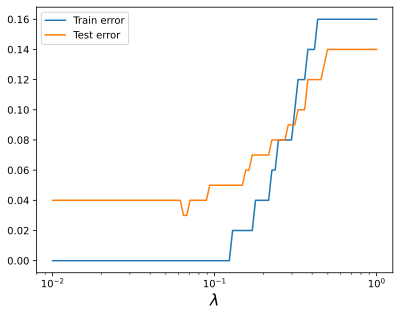

In [6]:
%matplotlib inline
%config InlineBackend.figure_format = "svg"

plt.plot(lambda_vals, train_error, label="Train error")
plt.plot(lambda_vals, test_error, label="Test error")
plt.xscale("log")
plt.legend(loc="upper left")
plt.xlabel(r"$\lambda$", fontsize=16)
plt.show()

### Regularization Path of Coefficients

The plot below shows how each component $\beta_i$ varies as $\lambda$ changes. For large $\lambda$ (right side), the $\ell_1$-penalty forces all coefficients to zero. As $\lambda$ decreases, coefficients "enter" the model one by one. The features that remain nonzero for the widest range of $\lambda$ are the most important -- these should correspond to the nonzero entries in $\beta_{\mathrm{true}}$.

In [ ]:
for i in range(n):
    plt.plot(lambda_vals, [wi[i] for wi in beta_vals])
plt.xlabel(r"$\lambda$", fontsize=16)
plt.xscale("log")

### Reconstruction Quality

We compare the true $\beta_{\mathrm{true}}$ with the reconstructed $\widehat{\beta}$ at the $\lambda$ that minimizes test error. The three truly nonzero coefficients ($\beta_0 = 1$, $\beta_1 = 0.5$, $\beta_2 = -0.5$) should be recovered accurately. A few spurious small nonzero values may appear due to finite-sample noise, but the dominant structure is correctly identified. This demonstrates the power of $\ell_1$-regularization for **sparse recovery** in high-dimensional settings ($n = 50$ features from only $m = 50$ samples).

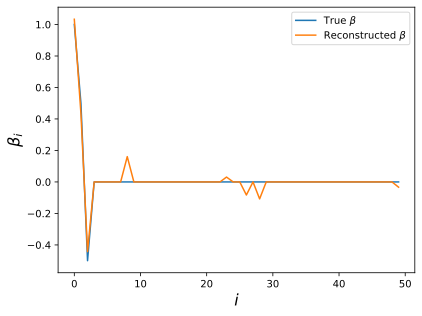

In [8]:
idx = np.argmin(test_error)
plt.plot(beta_true, label=r"True $\beta$")
plt.plot(beta_vals[idx], label=r"Reconstructed $\beta$")
plt.xlabel(r"$i$", fontsize=16)
plt.ylabel(r"$\beta_i$", fontsize=16)
plt.legend(loc="upper right")

## Summary

**Key takeaways from this notebook:**

1. **Logistic regression is convex.** The negative log-likelihood $-\sum_i [y_i \beta^\top x_i - \log(1 + e^{\beta^\top x_i})]$ is a convex function of $\beta$, so global optimization is tractable.

2. **$\ell_1$-regularization and sparsity.** Adding the penalty $\lambda\|\beta\|_1$ promotes sparse solutions where most coefficients are exactly zero. This performs automatic feature selection, which is especially valuable when $n$ (features) is comparable to or larger than $m$ (samples).

3. **Bias-variance trade-off.** The regularization parameter $\lambda$ controls model complexity. Too small $\lambda$ leads to overfitting; too large $\lambda$ leads to underfitting. The optimal $\lambda$ minimizes test error.

4. **Regularization path.** Plotting $\widehat{\beta}_i$ vs. $\lambda$ reveals which features are most important (they remain nonzero for larger $\lambda$). This is a practical tool for model interpretation in high-dimensional statistics.